# Ćwiczenia 9: podstawy statystyki z modułem SciPy

## Ćwiczenie 0.

Zaimportuj moduł Pandas oraz SciPy. Zaimportuj zestaw danych *environmental* i przygotuj do pracy.

In [1]:
import pandas as pd
import scipy 

In [2]:
sites = pd.read_csv("data/environmental/environmental/sites.csv", index_col="site_name").drop(columns=["comment"])

samples = pd.read_csv("data/environmental/environmental/samples.csv", index_col="sample_id").drop(columns=["comment"])
samples = samples.merge(sites, left_on="site", right_index=True, how="inner")[['site', 
                  'latitude', 'longitude', 'human_activity', 'season', 'depth', 'molecule', 'rep_number', 'temperature', 'humidity', 
                  'particles']]

taxa_db = pd.read_csv("data/environmental/environmental/taxa_db.csv", index_col=0)
taxonomy = pd.read_csv("data/environmental/environmental/taxonomy.csv", index_col="hash_id")
taxonomy = taxonomy.merge(taxa_db, left_on="taxonomy", right_index=True, how="inner")[['taxonomy_y', 'percentage']]
taxonomy.columns = ['taxonomy', 'percentage']

biom = pd.read_csv("data/environmental/environmental/biom.csv")
biom.index = biom.iloc[:, 0]
biom = biom.drop(columns=biom.columns[0])
biom.index.name = "sample_id"
biom = biom.map(lambda x: 0 if not isinstance(x, int) else x)

FileNotFoundError: [Errno 2] No such file or directory: 'data/environmental/environmental/sites.csv'

In [ ]:
samples.isna().sum()

site              0
latitude          0
longitude         0
human_activity    0
season            0
depth             0
molecule          0
rep_number        0
temperature       0
humidity          0
particles         0
dtype: int64

In [ ]:
samples.describe()

,latitude,longitude,depth,rep_number,temperature,humidity,particles
count,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000
mean,51.700633,19.805011,49.900415,2.944398,16.202490,56.449793,501.385703
std,0.828776,2.362234,24.484520,1.429772,7.446297,26.365187,245.436566
min,50.312115,15.493592,20.000000,1.000000,-4.000000,4.000000,4.621579
25%,51.067421,17.156424,20.000000,2.000000,11.000000,33.000000,326.248141
50%,51.904229,20.542271,50.000000,3.000000,16.000000,59.000000,509.809416
75%,52.088223,21.901493,80.000000,4.000000,21.000000,78.000000,680.624496
max,53.039363,22.739079,80.000000,5.000000,34.000000,99.000000,998.449089


<Axes: >

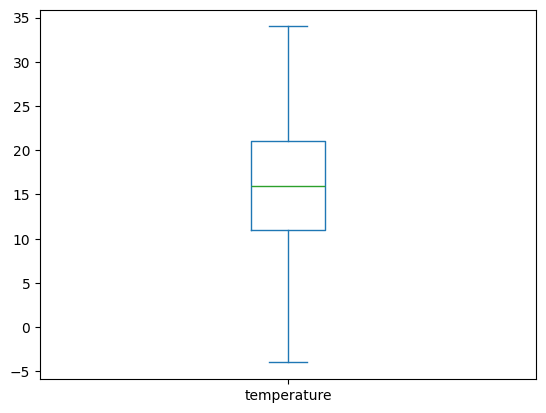

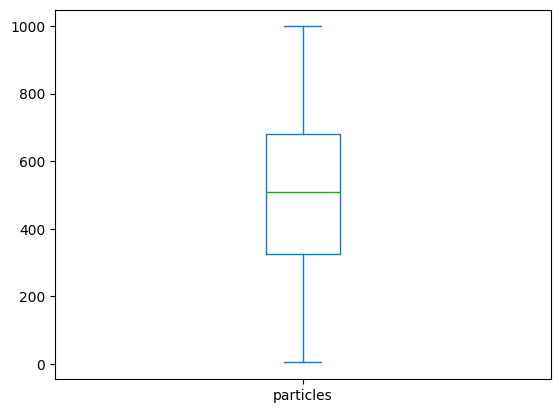

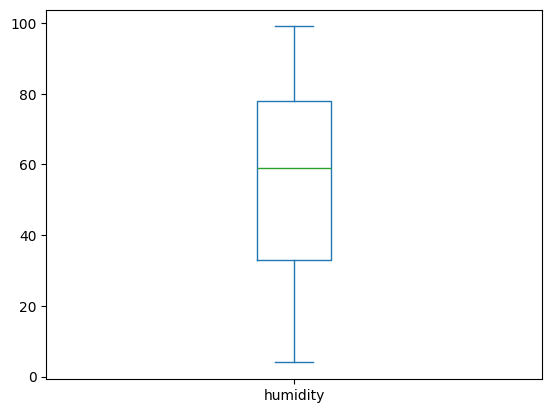

In [ ]:
samples[['temperature']].plot(kind = 'box');samples[['particles']].plot(kind = 'box');samples[['humidity']].plot(kind = 'box')

In [ ]:
samples = samples[(samples.temperature < 35) & (0 < samples.humidity) & (samples.humidity < 100) & (samples.particles >= 0) & (samples.particles < 1000)]

In [ ]:
taxonomy.isna().sum()

taxonomy      0
percentage    0
dtype: int64

In [ ]:
taxonomy.describe()

,percentage
count,3949.000000
mean,98.473662
std,1.441840
min,91.029628
25%,97.873126
50%,98.885349
75%,99.529270
max,99.998977


## Ćwiczenie 1. Testowanie założeń

Wiele testów statystycznych wymaga aby dane spełniały określone założenia. Na przykład test t-Studenta zakłada, że porównywane zmienne losowe mają rozkład normalny. Oznacza to, że wynik testu t-Studenta przeprowadzony na danych, które nie mają rozkładu normalnego jest niewiarygodny.

### Zadanie

Wykonaj test normalności Shapiro-Wilka na wszystkich zmiennych liczbowych z tabeli samples.
Wykonaj test niezależności wszystkich par zmiennych liczbowych z tabeli samples.

In [ ]:
def test_normal(zmienna_losowa):
    stats, p = scipy.stats.shapiro(zmienna_losowa)
    print(f"Statystyka testu: {stats}, p-value: {p}")
    if p > 0.05:
        print("Zmienna losowa jest rozkładu normalnego")
    else:
        print("Zmienna losowa nie jest rozkładu normalnego")


In [ ]:
def test_normalnosci(zmienna_losowa):
    statistic, p = scipy.stats.shapiro(zmienna_losowa)
    print(f'Wartość statystyki testowej = {statistic:.3f}, p-value = {p:.3f}')
    if p < 0.05:
        print('Zmienna nie ma rozkładu normalnego')
    else:
        print('Zmienna ma rozkłąd normalny')
    

In [ ]:
samples.head()

,site,latitude,longitude,human_activity,season,depth,molecule,rep_number,temperature,humidity,particles
sample_id,,,,,,,,,,,
1,site_1,52.044225,18.228474,urban,spring,20.0,DNA,1.0,13.0,48.0,487.171474
2,site_1,52.044225,18.228474,urban,spring,20.0,RNA,1.0,13.0,48.0,561.125523
3,site_1,52.044225,18.228474,urban,spring,50.0,DNA,1.0,13.0,48.0,315.156923
5,site_1,52.044225,18.228474,urban,spring,80.0,DNA,1.0,13.0,48.0,282.204666
6,site_1,52.044225,18.228474,urban,spring,80.0,RNA,1.0,13.0,48.0,487.280159


In [ ]:
test_normalnosci(samples.temperature)
test_normalnosci(samples.humidity)
test_normalnosci(samples.particles)

Wartość statystyki testowej = 0.993, p-value = 0.000
Zmienna nie ma rozkładu normalnego
Wartość statystyki testowej = 0.953, p-value = 0.000
Zmienna nie ma rozkładu normalnego
Wartość statystyki testowej = 0.981, p-value = 0.000
Zmienna nie ma rozkładu normalnego


In [ ]:
def test_niezaleznosci(zmienna1, zmienna2):
   statistics, p = scipy.stats.levene(zmienna1, zmienna2)
   print(f'Wartość statystyki testowej = {statistics:.3f}, p-value = {p:.3f}')
   if p < 0.05:
        print('Zmienne są zależne')
   else:
        print('Zmienne są niezależne')

    

In [ ]:
test_niezaleznosci(samples.temperature, samples.humidity)
test_niezaleznosci(samples.temperature, samples.particles)
test_niezaleznosci(samples.humidity, samples.particles)


Wartość statystyki testowej = 1707.897, p-value = 0.000
Zmienne są zależne
Wartość statystyki testowej = 2488.003, p-value = 0.000
Zmienne są zależne
Wartość statystyki testowej = 2062.732, p-value = 0.000
Zmienne są zależne


## Ćwiczenie 2. Testowanie hipotez

Przetestuj następujące hipotezy:
* średnia temperatura latem jest istotnie wyższa niż wiosną i jesienią
* średnia wilgotność powietrza jesienią jest istotnie wyższa niż wiosną
* średnia liczba ASV w próbkach na DNA jest istotnie niższa niż w próbkach na RNA
* średnia liczba cząsteczek na głębokości 80 cm jest istotnie wyższa niż na głębokości 20 cm
* średnia bioróżnorodność na południu kraju jest istotnie wyższa niż na północy

# H0
h0: EX_lato <= EX_wiosna i EX_lato <= EX_jesien

h1 : EX_lato > EX_wiosna i EX_lato > EX_jesien

<Axes: xlabel='season'>

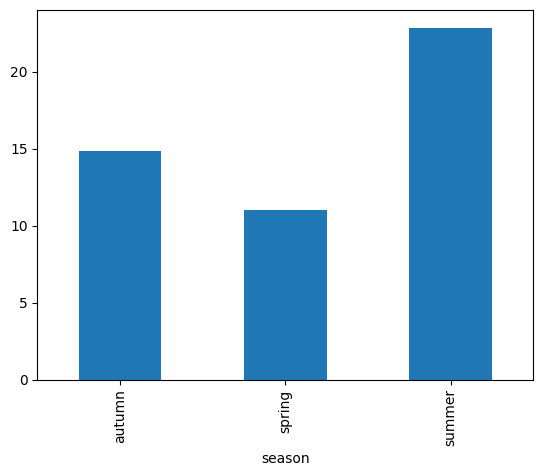

In [ ]:
# to tylko moje sprawdzenie, czy wszystko działa, nie jest częścią zadania
zmienna =samples.groupby("season").temperature.mean()
zmienna.plot(kind="bar")

In [ ]:
temp_lato = samples[samples.season == "summer"].temperature
temp_wiosna = samples[samples.season == "spring"].temperature
temp_jesien = samples[samples.season == "autumn"].temperature

In [ ]:
temp_lato

sample_id
31      15.0
32      15.0
33      15.0
34      15.0
35      15.0
        ... 
1406    16.0
1407    16.0
1408    16.0
1409    16.0
1410    16.0
Name: temperature, Length: 393, dtype: float64

In [ ]:
test_normalnosci(temp_lato)
test_normalnosci(temp_wiosna)
test_normalnosci(temp_jesien)

Wartość statystyki testowej = 0.976, p-value = 0.000
Zmienna nie ma rozkładu normalnego
Wartość statystyki testowej = 0.984, p-value = 0.000
Zmienna nie ma rozkładu normalnego
Wartość statystyki testowej = 0.942, p-value = 0.000
Zmienna nie ma rozkładu normalnego


In [ ]:
test_niezaleznosci(temp_lato, temp_wiosna)
test_niezaleznosci(temp_lato, temp_jesien)
test_niezaleznosci(temp_wiosna, temp_jesien)

Wartość statystyki testowej = 8.092, p-value = 0.005
Zmienne są zależne
Wartość statystyki testowej = 0.216, p-value = 0.642
Zmienne są niezależne
Wartość statystyki testowej = 8.632, p-value = 0.003
Zmienne są zależne


In [ ]:
temp_lato.size

393

In [ ]:
temp_jesien.size

414

In [ ]:
temp_wiosna.size

398

In [ ]:
temp_wiosna = temp_wiosna.iloc[:393]
temp_jesien = temp_jesien.iloc[:393]

In [ ]:
scipy.stats.wilcoxon(temp_lato, temp_wiosna)
scipy.stats.wilcoxon(temp_lato, temp_jesien)
#odrzucamy h0 i przyjmujemy h1 

WilcoxonResult(statistic=np.float64(410.0), pvalue=np.float64(1.1365570021668773e-64))

## Ćwiczenie 3. Testowanie hipotez między wieloma zmiennymi

Podstawowe testy statystyczne badają różnice między parami zmiennych losowych. Czasem zachodzi potrzeba porównać więcej niż dwie zmienne równocześnie. Służy do tego analiza wariancji i test ANOVA. Ten test porównuje wariancję wewnątrz grup do wariancji między grupami. Odpowiada na pytanie *czy przynajmniej jedna grupa ma inną średnią niż pozostałe*.

Przetestuj następujące hipotezy:
* średnia liczba ASV istotnie różni się między poszczególnymi powtórzeniami na stanowiskach
* średnia bioróżnorodność istotnie różni się między próbkami z poszczególnych kwadrantów kraju (pólnocny wschód, południowy wschód, północny zachód, południowy zachód)

## Ćwiczenie 4. Testowanie korelacji

Korelacja to test, który bada współzależność dwóch zmiennych losowych. Służy do poszukiwania zależności przyczynowo skutkowych, ale **sama istotność korelacji nie oznacza istnienia związku przyczynowo-skutkowego**. Jest tylko punktem wyjścia do dalszych badań.

Przetestuj następujące hipotezy:
* oceń związek między temperaturą a wilgotnością w próbkach z północy
* oceń związek między porą roku, a temperaturą
* oceń związek między liczbą cząsteczek próbce, a wartością richness w każdej próbce na stanowisku 3 i 4
* oceń związek między głębokością a liczbą cząsteczek w próbkach ze wschodu kraju
* oceń związek między typem molekuły, a bioróżnorodnością Shannona w próbkach na wiosnę

## Ćwiczenie 5. Odległości

Obliczanie odległości jest kluczowe w analizie danych. Odległość między próbkami ocenia stopień podobieństwa, a co za tym idzie pozwala uzyskać obraz pewnej rzeczywistości i porównać ją ze sobą. Wyróżniamy wiele miar i niektóre z nich są ogólne (np. odległość Minkowskiego), a niektóre mają bardzo specyficzne zastosowania (np. odległość Bray-Curtis).

Oblicz następujące odległości:
* odległość Jaccarda między dwiema wybranymi próbkami
* odległość Euklidesa między losową próbką z północy, a losową próbką z południa
* odległość Minkowskiego przy $p=2$ między tymi samymi próbkami co w podpunkcie powyżej
* odległość Bray-Curtis między wszystkimi parami próbek
* macierz odległości Euklidesa między wszystkimi parami próbek